<a href="https://colab.research.google.com/github/rastri-dey/Ground-up-implementations-ML-algorithms-/blob/main/notebooks/CNN_mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Description:

*   The main goal of this notebook is to show the same CNN model can be used regardless of the image dimension & class size for different datasets. The class is constructed such that varying inputs, outputs dimensions doesn't matter.
*   We are using the same CNN class from CIFAR10 model training




## Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time
import os

# Check the device enabled

In [ ]:
print(torch.__version__)
if torch.cuda.is_available():
  device = torch.device('cuda:0')
else:
  device = torch.device('cpu')
print(device)

2.8.0+cu126
cuda:0


## Import Datasets - MNIST

5 torch.Size([1, 28, 28])


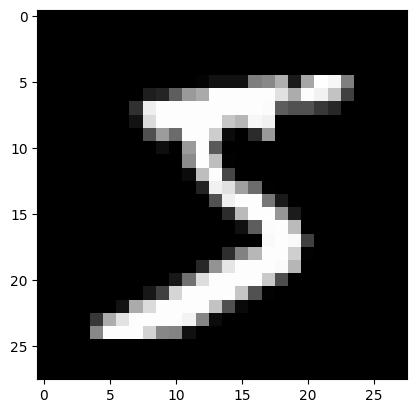

In [ ]:
folder = "data"
mnist_train = datasets.MNIST(folder, train = True, download = True, transform = transforms.ToTensor())
mnist_test = datasets.MNIST(folder, train = False, download = True, transform = transforms.ToTensor())
print(mnist_train[0][1], mnist_train[0][0].shape)
plt.imshow(mnist_train[0][0].permute(1,2,0), cmap='gray')

## Normalize the Dataset

torch.Size([1, 28, 28, 60000])
torch.Size([1, 47040000])
tensor([0.1307]) tensor([0.3081])
5 torch.Size([1, 28, 28])


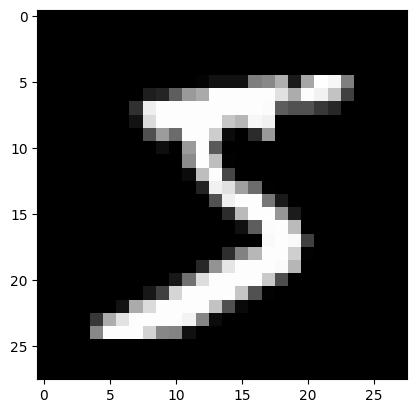

In [ ]:
img_stack = torch.stack([img for img, _ in mnist_train], dim=3)
print(img_stack.shape)
img_flat = img_stack.view(1, -1)
print(img_flat.shape)
mu = img_flat.mean(dim = 1)
sigma = img_flat.std(dim=1)
print(mu, sigma)

mnist_train = datasets.MNIST(folder,
                             train = True,
                             download = False,
                             transform = transforms.Compose([
                                 transforms.ToTensor(),
                                 transforms.Normalize(mu, sigma)
                             ]))

mnist_val = datasets.MNIST(folder,
                           train = False,
                           download = False,
                           transform = transforms.Compose([
                               transforms.ToTensor(),
                               transforms.Normalize(mu, sigma)
                           ]))
print(mnist_train[0][1], mnist_train[0][0].shape)
plt.imshow(mnist_train[0][0].permute(1,2,0), cmap='gray')

## Define the CNN Model
This is the same CNN Model defined for CIFAR10 dataset

In [ ]:
class NeuralNet(nn.Module):
  def __init__(self, img, nclasses, nchannels = 16, nhidden = 32, kernel_size = 3):
    super().__init__()
    C, H, W = img.shape
    self.conv1 = nn.Conv2d(C, nchannels, kernel_size = kernel_size, padding = kernel_size//2)

##